# 06 Marker Gene Dot Plots on Log-Normalized Expression

Use this notebook when the goal is to compare marker genes between Kallies single-cell conditions. It rebuilds expression from `layers["counts"]`, applies `normalize_total` + `log1p`, and plots marker genes from log-normalized values. It does not use scaled `.X` values.


In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from src.paths import INTERMEDIATE_DIR, RESULTS_DIR, REPO_DIR

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=110, facecolor="white")


/tmp/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-42uyt4fc because there was an issue with the default path (/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/tmp/ipykernel_903912/3630201886.py:17: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110, facecolor="white")


## Marker Gene Sheet

Edit `data/marker_gene_panels.csv` to change the plotted genes. Required columns are `panel`, `gene`, and `display_order`. Keep gene symbols in mouse case, for example `Klf2`, not `KLF2`.


In [3]:
input_file = INTERMEDIATE_DIR / "04_cell_annotation.h5ad"
marker_sheet = REPO_DIR / "data" / "marker_gene_panels.csv"
output_dir = RESULTS_DIR / "06_marker_gene_dotplots_lognormalized"
output_dir.mkdir(parents=True, exist_ok=True)

# Main plot settings.
condition_order = ["IEL_memory", "LPL_memory", "rechallenge"]
cluster_key = "leiden_0_5"
detection_threshold = 0.0
save_cell_level_table = False

marker_sheet


PosixPath('/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025/data/marker_gene_panels.csv')

In [4]:
markers = pd.read_csv(marker_sheet)
required_columns = {"panel", "gene", "display_order"}
missing_columns = required_columns.difference(markers.columns)
if missing_columns:
    raise ValueError(f"Marker sheet is missing required columns: {sorted(missing_columns)}")

markers = markers.dropna(subset=["panel", "gene"]).copy()
markers["gene"] = markers["gene"].astype(str).str.strip()
markers["panel"] = markers["panel"].astype(str).str.strip()
markers["display_order"] = pd.to_numeric(markers["display_order"], errors="coerce")
markers = markers.sort_values(["display_order", "panel", "gene"])
marker_genes = markers["gene"].drop_duplicates().tolist()
panel_for_gene = markers.drop_duplicates("gene").set_index("gene")["panel"].to_dict()

markers


,panel,gene,display_order
0,egress,Ccr7,1
1,egress,S1pr1,2
2,egress,Klf2,3
3,program,Tgfbr1,4
4,program,Runx3,5
5,program,Itgar,6
6,retention,Cd69,7
7,retention,Cxcr6,8


## Load Annotated Data and Rebuild Log-Normalized Expression


In [5]:
adata = sc.read_h5ad(input_file)

adata.obs["condition"] = adata.obs["sample_group"].map(
    {
        "sIEL": "IEL_memory",
        "sLPL": "LPL_memory",
        "rechallenge": "rechallenge",
    }
)
adata.obs["condition"] = pd.Categorical(adata.obs["condition"], categories=condition_order, ordered=True)

expr_adata = adata.copy()
if "counts" in expr_adata.layers:
    expr_adata.X = expr_adata.layers["counts"].copy()
elif "raw_counts" in expr_adata.layers:
    expr_adata.X = expr_adata.layers["raw_counts"].copy()
else:
    raise ValueError("No raw count layer found. Expected layers['counts'] or layers['raw_counts'].")

expr_adata.uns.pop("log1p", None)
sc.pp.normalize_total(expr_adata, target_sum=1e4)
sc.pp.log1p(expr_adata)

present_genes = [gene for gene in marker_genes if gene in expr_adata.var_names]
missing_genes = sorted(set(marker_genes).difference(present_genes))
print("Present genes:", present_genes)
print("Missing genes:", missing_genes)

if not present_genes:
    raise ValueError("None of the marker genes were found in the AnnData object.")

expr_adata


normalizing counts per cell


/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


    finished (0:00:03)
Present genes: ['Ccr7', 'S1pr1', 'Klf2', 'Tgfbr1', 'Runx3', 'Cd69', 'Cxcr6']
Missing genes: ['Itgar']


AnnData object with n_obs × n_vars = 13206 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3', 'leiden_0_5', 'cell_type_manual', 'cd8_subset', 'condition'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_manual_colors', 'hash_id_colors', 'hvg', 'leiden_0_5', 'leiden_0_5_colors', 'neighbors', 'pca', 'rank_genes_gr

## Build Long Expression Table


In [6]:
expr = sc.get.obs_df(expr_adata, keys=present_genes, use_raw=False)
expr["condition"] = expr_adata.obs["condition"].values
expr["sample_group"] = expr_adata.obs["sample_group"].values
expr[cluster_key] = expr_adata.obs[cluster_key].astype(str).values

expr_long = expr.melt(
    id_vars=["condition", "sample_group", cluster_key],
    value_vars=present_genes,
    var_name="gene",
    value_name="log1p_normalized_expression",
)
expr_long["detected"] = expr_long["log1p_normalized_expression"].gt(detection_threshold)
expr_long["panel"] = expr_long["gene"].map(panel_for_gene)
expr_long["gene"] = pd.Categorical(expr_long["gene"], categories=present_genes, ordered=True)

if save_cell_level_table:
    cell_file = output_dir / "marker_gene_log_normalized_expression_by_cell.tsv"
    expr_long.to_csv(cell_file, sep="	", index=False)
    print("Saved:", cell_file)

expr_long.head()


,condition,sample_group,leiden_0_5,gene,log1p_normalized_expression,detected,panel
0,LPL_memory,sLPL,5,Ccr7,0.0,False,egress
1,rechallenge,rechallenge,0,Ccr7,0.0,False,egress
2,IEL_memory,sIEL,6,Ccr7,0.0,False,egress
3,IEL_memory,sIEL,2,Ccr7,0.0,False,egress
4,IEL_memory,sIEL,2,Ccr7,0.0,False,egress


## Summaries by Condition and Cluster


In [7]:
def summarize_expression(df, group_cols):
    out = (
        df.groupby(group_cols + ["panel", "gene"], observed=True)
        .agg(
            mean_log1p=("log1p_normalized_expression", "mean"),
            median_log1p=("log1p_normalized_expression", "median"),
            pct_detected=("detected", "mean"),
            n_cells=("log1p_normalized_expression", "size"),
        )
        .reset_index()
    )
    out["pct_detected"] *= 100
    return out

summary_by_condition = summarize_expression(expr_long, ["condition"])
summary_by_cluster = summarize_expression(expr_long, [cluster_key])
summary_by_condition_cluster = summarize_expression(expr_long, ["condition", cluster_key])

condition_file = output_dir / "marker_gene_lognorm_summary_by_condition.tsv"
cluster_file = output_dir / "marker_gene_lognorm_summary_by_cluster.tsv"
condition_cluster_file = output_dir / "marker_gene_lognorm_summary_by_condition_cluster.tsv"

summary_by_condition.to_csv(condition_file, sep="	", index=False)
summary_by_cluster.to_csv(cluster_file, sep="	", index=False)
summary_by_condition_cluster.to_csv(condition_cluster_file, sep="	", index=False)

print("Saved:", condition_file)
print("Saved:", cluster_file)
print("Saved:", condition_cluster_file)
summary_by_condition


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_lognorm_summary_by_condition.tsv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_lognorm_summary_by_cluster.tsv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_lognorm_summary_by_condition_cluster.tsv


,condition,panel,gene,mean_log1p,median_log1p,pct_detected,n_cells
0,IEL_memory,egress,Ccr7,0.019397,0.000000,1.851483,5023
1,IEL_memory,egress,S1pr1,0.049417,0.000000,4.857655,5023
2,IEL_memory,egress,Klf2,0.473608,0.000000,29.623731,5023
3,IEL_memory,program,Tgfbr1,0.117288,0.000000,11.646426,5023
4,IEL_memory,program,Runx3,1.733177,1.833065,90.324507,5023
5,IEL_memory,retention,Cd69,1.825729,1.968003,85.068684,5023
6,IEL_memory,retention,Cxcr6,1.338979,1.477513,80.171212,5023
7,LPL_memory,egress,Ccr7,0.016153,0.000000,1.882796,4249
8,LPL_memory,egress,S1pr1,0.156536,0.000000,14.638739,4249
9,LPL_memory,egress,Klf2,0.452587,0.000000,28.383149,4249


## Pretty Dot Plot Function


In [ ]:
def make_marker_dotplot(summary, group_col, group_order, title, output_stem):
    plot_df = summary.copy()
    plot_df = plot_df[plot_df["gene"].isin(present_genes)].copy()
    plot_df["gene"] = pd.Categorical(plot_df["gene"].astype(str), categories=list(reversed(present_genes)), ordered=True)
    plot_df[group_col] = pd.Categorical(plot_df[group_col].astype(str), categories=[str(x) for x in group_order], ordered=True)
    plot_df = plot_df.dropna(subset=[group_col, "gene"])
    plot_df["x"] = plot_df[group_col].cat.codes
    plot_df["y"] = plot_df["gene"].cat.codes

    width = max(5.5, 0.45 * len(group_order) + 2.5)
    height = max(4.2, 0.46 * len(present_genes) + 1.4)
    fig, ax = plt.subplots(figsize=(width, height))

    sizes = 24 + plot_df["pct_detected"].fillna(0) / 100 * 320
    color_values = plot_df["mean_log1p"].fillna(0)
    scatter = ax.scatter(
        plot_df["x"],
        plot_df["y"],
        s=sizes,
        c=color_values,
        cmap="viridis",
        edgecolor="0.25",
        linewidth=0.5,
    )

    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels([str(x) for x in group_order], rotation=35, ha="right")
    ax.set_yticks(range(len(present_genes)))
    ax.set_yticklabels(list(reversed(present_genes)))
    ax.set_xlabel(group_col)
    ax.set_ylabel("marker gene")
    ax.set_title(title)
    ax.grid(axis="both", color="0.9", linewidth=0.7)
    ax.set_axisbelow(True)

    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("mean log1p normalized expression")

    legend_values = [10, 25, 50, 75, 100]
    handles = [
        ax.scatter([], [], s=24 + value / 100 * 320, color="white", edgecolor="0.25", linewidth=0.5)
        for value in legend_values
    ]
    ax.legend(
        handles,
        [f"{value}%" for value in legend_values],
        title="detected",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.18, 1.0),
    )

    # Draw panel separators on the y-axis.
    gene_to_panel = [panel_for_gene[gene] for gene in reversed(present_genes)]
    for i in range(1, len(gene_to_panel)):
        if gene_to_panel[i] != gene_to_panel[i - 1]:
            ax.axhline(i - 0.5, color="0.2", linewidth=0.8)

    fig.tight_layout()
    png = output_dir / f"{output_stem}.png"
    pdf = output_dir / f"{output_stem}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)
    return fig, ax


## Dot Plots by Condition and Cluster


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_dotplot_by_condition_lognormalized.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_dotplot_by_condition_lognormalized.pdf
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_dotplot_by_cluster_lognormalized.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_dotplot_by_cluster_lognormalized.pdf


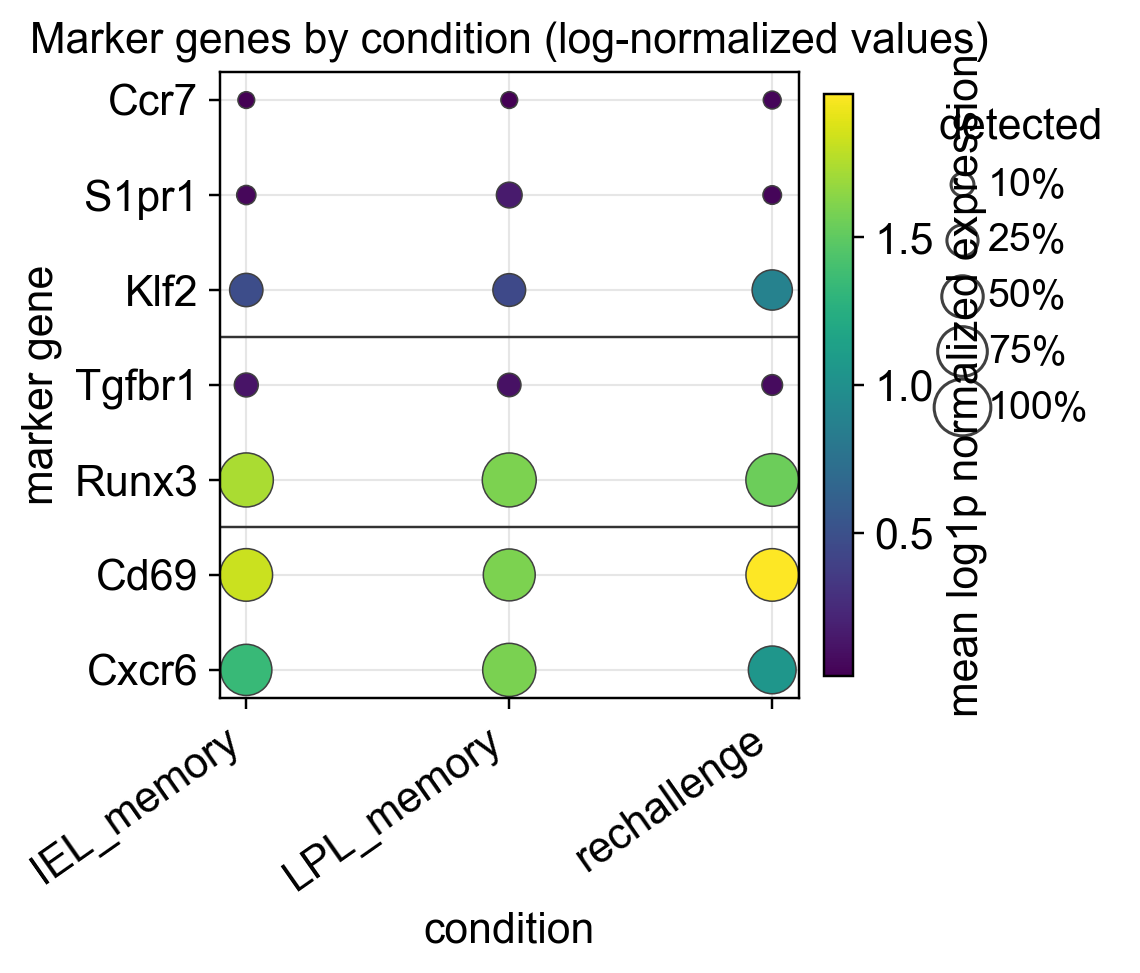

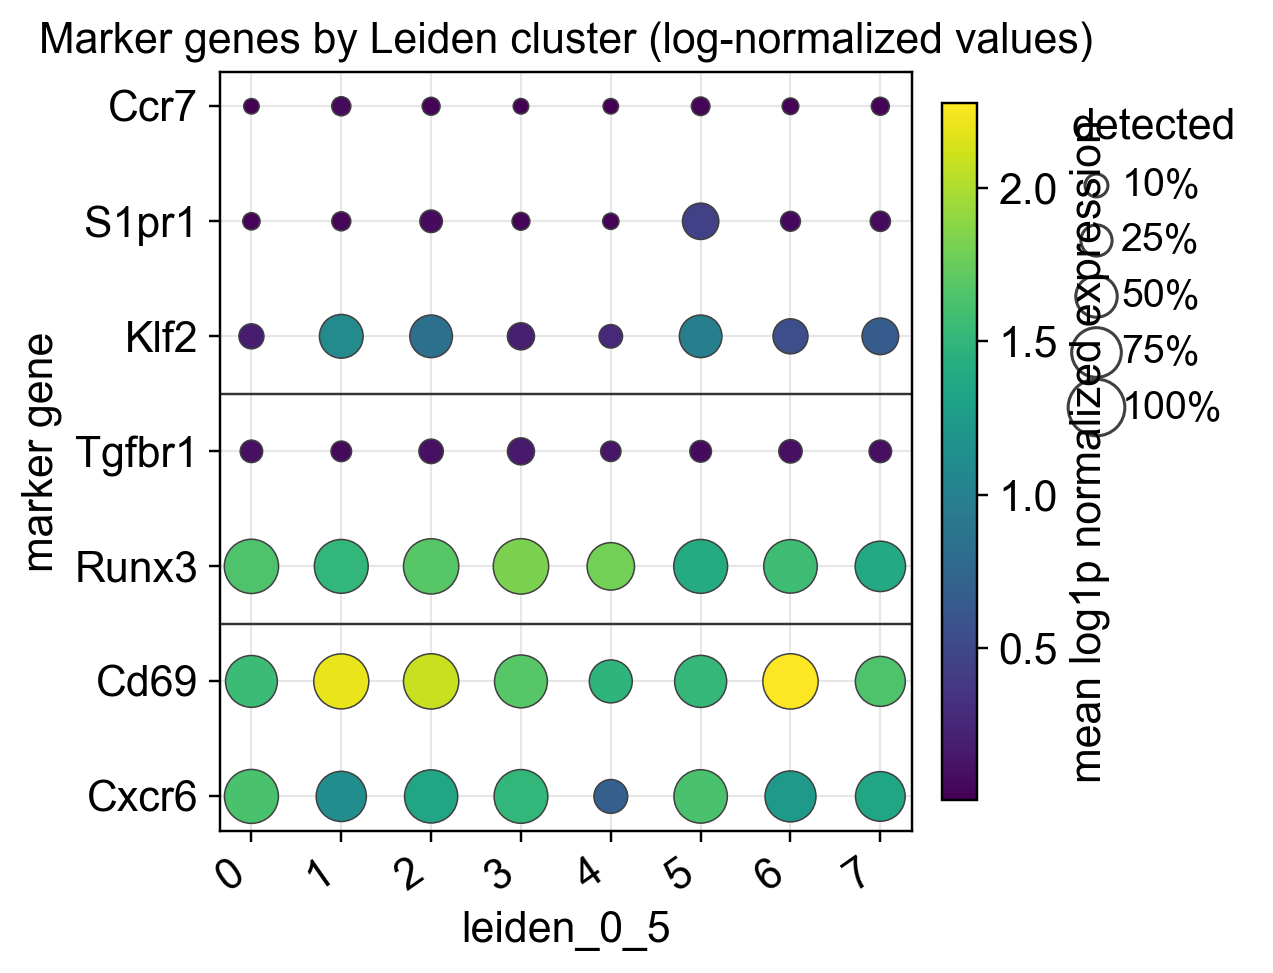

In [11]:
fig_condition, ax_condition = make_marker_dotplot(
    summary=summary_by_condition,
    group_col="condition",
    group_order=condition_order,
    title="Marker genes by condition (log-normalized values)",
    output_stem="marker_gene_dotplot_by_condition_lognormalized",
)

cluster_order = sorted(expr_long[cluster_key].astype(str).unique(), key=lambda x: int(x) if x.isdigit() else x)
fig_cluster, ax_cluster = make_marker_dotplot(
    summary=summary_by_cluster,
    group_col=cluster_key,
    group_order=cluster_order,
    title="Marker genes by Leiden cluster (log-normalized values)",
    output_stem="marker_gene_dotplot_by_cluster_lognormalized",
)


## Condition x Cluster Dot Plot

This plot is useful when a marker appears condition-specific but may actually be concentrated in one or two clusters.


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_dotplot_by_condition_cluster_lognormalized.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_dotplot_by_condition_cluster_lognormalized.pdf


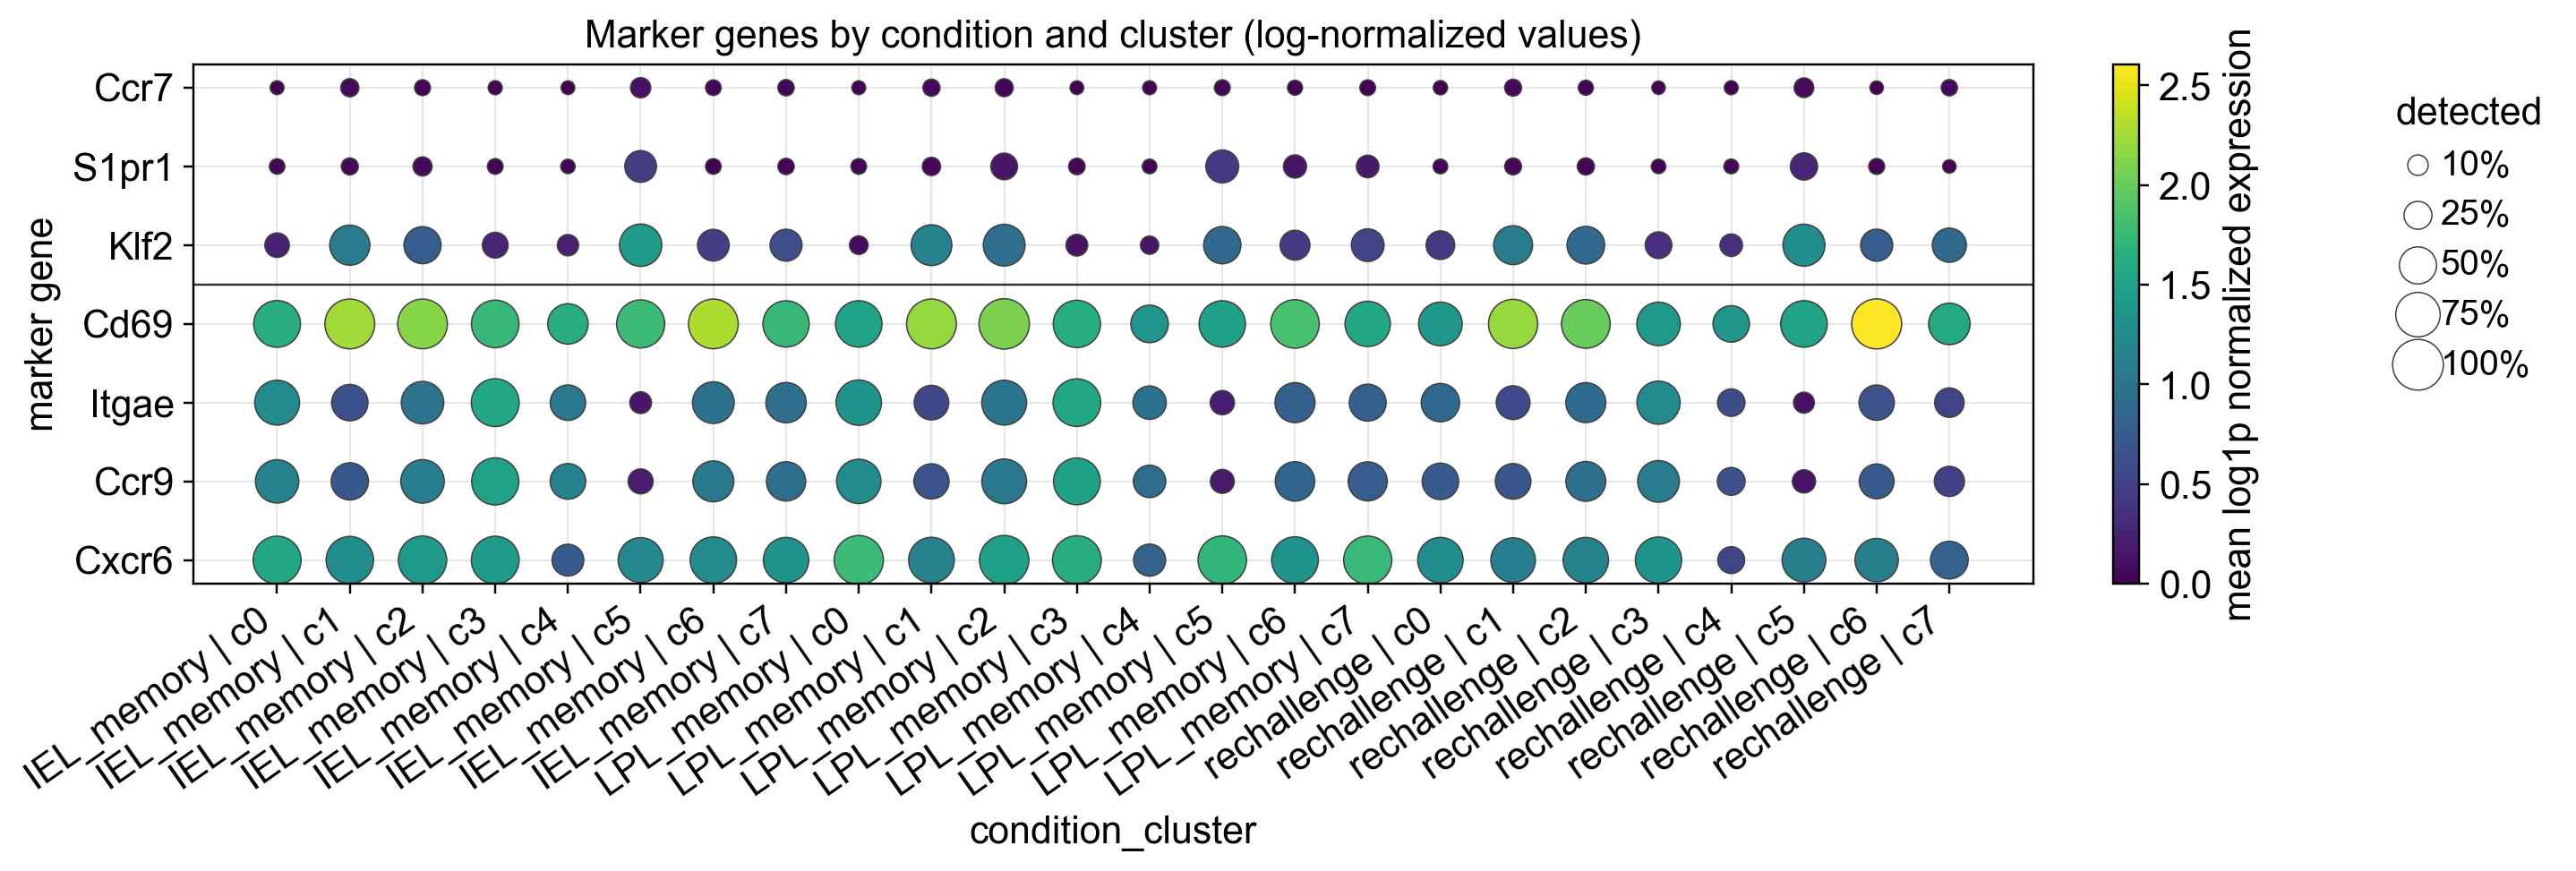

In [9]:
condition_cluster_summary = summary_by_condition_cluster.copy()
condition_cluster_summary["condition_cluster"] = (
    condition_cluster_summary["condition"].astype(str) + " | c" + condition_cluster_summary[cluster_key].astype(str)
)
condition_cluster_order = [
    f"{condition} | c{cluster}"
    for condition in condition_order
    for cluster in cluster_order
    if f"{condition} | c{cluster}" in set(condition_cluster_summary["condition_cluster"])
]

fig_condition_cluster, ax_condition_cluster = make_marker_dotplot(
    summary=condition_cluster_summary.rename(columns={"condition_cluster": "condition_cluster"}),
    group_col="condition_cluster",
    group_order=condition_cluster_order,
    title="Marker genes by condition and cluster (log-normalized values)",
    output_stem="marker_gene_dotplot_by_condition_cluster_lognormalized",
)


## UMAP Expression Panels


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_umap_lognormalized_expression.png
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_umap_lognormalized_expression.pdf


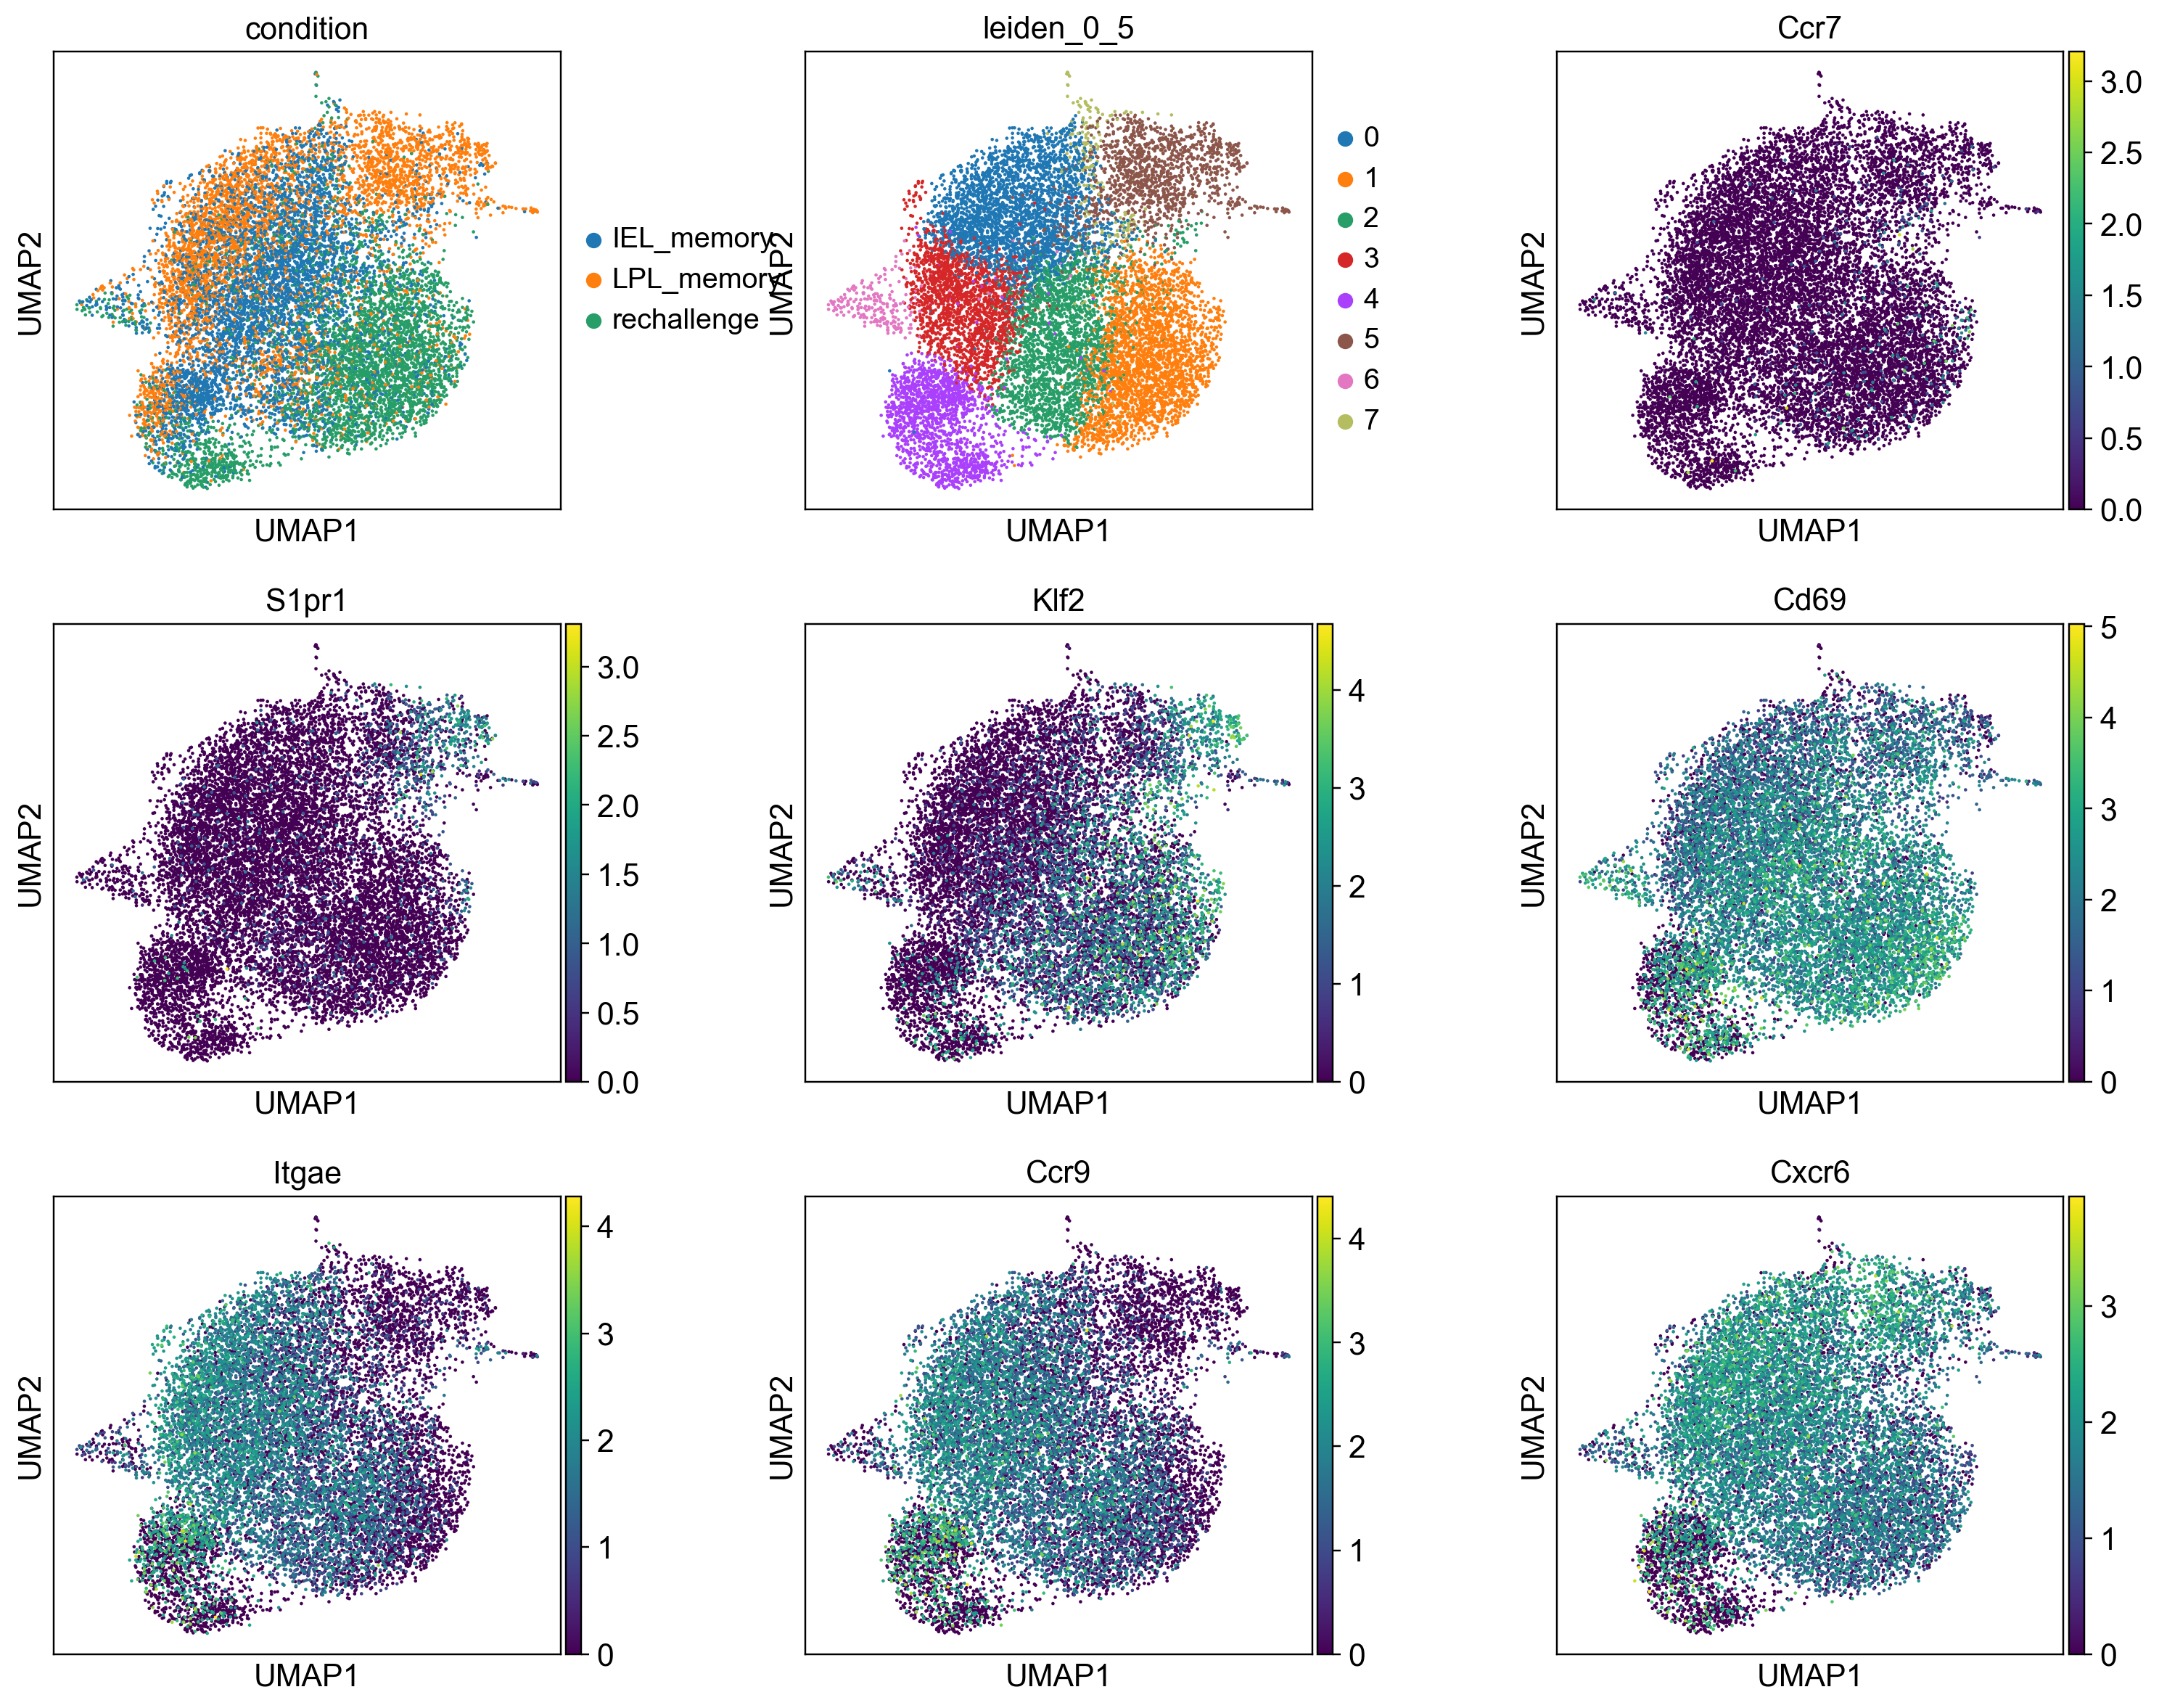

In [10]:
sc.pl.umap(
    expr_adata,
    color=["condition", cluster_key] + present_genes,
    use_raw=False,
    ncols=3,
    wspace=0.35,
    show=False,
)
fig = plt.gcf()
umap_png = output_dir / "marker_gene_umap_lognormalized_expression.png"
umap_pdf = output_dir / "marker_gene_umap_lognormalized_expression.pdf"
fig.savefig(umap_png, bbox_inches="tight")
fig.savefig(umap_pdf, bbox_inches="tight")
print("Saved:", umap_png)
print("Saved:", umap_pdf)


## Quick Pairwise Condition Deltas

These are simple differences in mean log-normalized expression, not differential-expression statistics.


In [11]:
mean_matrix = (
    summary_by_condition.pivot(index="gene", columns="condition", values="mean_log1p")
    .reindex(index=present_genes, columns=condition_order)
)
condition_deltas = pd.DataFrame(index=mean_matrix.index)
if {"IEL_memory", "LPL_memory"}.issubset(mean_matrix.columns):
    condition_deltas["IEL_memory_minus_LPL_memory"] = mean_matrix["IEL_memory"] - mean_matrix["LPL_memory"]
if {"rechallenge", "LPL_memory"}.issubset(mean_matrix.columns):
    condition_deltas["rechallenge_minus_LPL_memory"] = mean_matrix["rechallenge"] - mean_matrix["LPL_memory"]
if {"rechallenge", "IEL_memory"}.issubset(mean_matrix.columns):
    condition_deltas["rechallenge_minus_IEL_memory"] = mean_matrix["rechallenge"] - mean_matrix["IEL_memory"]
condition_deltas.insert(0, "panel", [panel_for_gene[gene] for gene in condition_deltas.index])

delta_file = output_dir / "marker_gene_mean_lognorm_condition_deltas.tsv"
condition_deltas.to_csv(delta_file, sep="	")
print("Saved:", delta_file)
condition_deltas


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_marker_gene_dotplots_lognormalized/marker_gene_mean_lognorm_condition_deltas.tsv


,panel,IEL_memory_minus_LPL_memory,rechallenge_minus_LPL_memory,rechallenge_minus_IEL_memory
gene,,,,
Ccr7,egress,0.003245,0.024630,0.021385
S1pr1,egress,-0.107119,-0.114407,-0.007288
Klf2,egress,0.021021,0.436297,0.415276
Cd69,retention,0.227818,0.387057,0.159239
Itgae,retention,0.177678,-0.291273,-0.468950
Ccr9,retention,0.223003,-0.182769,-0.405772
Cxcr6,retention,-0.252108,-0.543454,-0.291346
